# Stellar Clustering: Evaluating Clustering Methods for Reconstructing Hertzsprung–Russell Diagrams

Independent research project for the **Women in Mathematics Directed Research Program (S26)** at the University of Waterloo, supervised by mentors Téa Fazio and Gaia Noseworthy.
- Project was performed in reference to work by [Amelia Robles Delgaro](https://github.com/Ameliarbls/gaia-hr-diagram) and [Rohan Paul](https://github.com/rohanpauldev/hr-diagram-clustering-gaia-dr3)


***

## Overview:

This project uses a quality filtered sample of Gaia Data Release 3 (DR3) stellar data to construct a Hertzsprung-Russel (HR) diagram, and performs unsupervised clustering using K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise), and GMM (Gaussian Mixture Modelling). The goal is to investigate whether these unsupervised clustering methods can recover meaningful stellar population groupings within the HR diagram, and determine which method gives the most astronomically informative results.

***


## Research Question:

**Can unsupervised clustering of random Gaia DR3 star data return a plot similar to the Hertzsprung-Russell diagram? If so, which clustering method out of K-means, DBSCAN, GMM gives the best result?**

***

## Project Workflow:
- Collect a quality filtered data set from Gaia DR3
- Calculate absolute magnitude values from apparent magnitude and parallax required for plotting an HR diagram
- Plot BP-RP colour index vs. absolute magnitude graph
- Perform unsupervised clustering on graph using outlined methods
- Analyze resulting plots, discuss limitations, and draw conclusions
- Discuss potential directions for future work

***

## Background:

- A **Hertzsprung-Russell (HR) diagram** is a scatter plot of stars based on their physical attributes, showing the relationship between the star's *stellar classification* (colour index/effective temperature) and *absolute magnitude* (brightness). This diagram was created independently by Ejnar Hertzsprung in 1911, and Henry Norris Russel in 1913, and is used to classify and investigate the evolutionary stages of stars.
    - The **horizontal axis** shows the colour of the star, or its effective temperature. In the HR diagram, blue stars appear towards the left, and red stars appear towards the right.
    - The **verticle axis** shows the absolute magnitude of the star, which is a standardized brightness measurement. Brighter stars appear on the top, and dimmer stars appear at the bottom.

- **[Gaia Data Release 3 (DR3)](https://www.cosmos.esa.int/web/gaia/dr3)** is a public catalog of astronomical data released by the European Space Agency on June 13, 2022, and provides emasurements for stellar positions and movements, parallax, and physical traits for over 1.8 billion cosmic objects. 


***

## Tools used:


### Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

### Data access method and ADQL Query:

Gaia DR3 data is publically available from the [Gaia Archive](https://gea.esac.esa.int/archive/) using an ADQL (Astronomical Data Query Language) query, which is a specialized variant of SQL used to query large astronomy datasets. The below code is a query for a quality-filtered, random subset of 10000 stellar sources, which can be directly pasted to **search > Advanced (ADQL)**.

In [ ]:
# Data query (copy and paste uncommented code into query box)

# SELECT TOP 10000
#     gs.source_id,
#     gs.ra,
#     gs.dec,

#     -- Astrometric information
#     gs.parallax,
#     gs.parallax_over_error,

#     -- Gaia photometry
#     gs.phot_g_mean_mag,
#     gs.bp_rp,

#     -- Photometric and astrometric quality
#     gs.ruwe

# FROM gaiadr3.gaia_source AS gs

# -- Data quality filtering
# WHERE gs.parallax > 0
#   AND gs.phot_g_mean_mag IS NOT NULL
#   AND gs.parallax_over_error > 10
#   AND gs.bp_rp IS NOT NULL
#   AND gs.ruwe < 1.4
#   AND gs.random_index < 500000;

### Variables collected:

<div align="center">

| Column | Description | Role |
|:---|:---|:---|
| **`source_id`** | Unique Gaia identifier | Row identifier |
| **`ra`** | Right ascension | Measure of star's position eastward along celestial equator ('longitude' coordinate) |
| **`dec`** | Declination | Measure of star's north or south position along celestial equator ('latitude' coordinate) |
| **`parallax`** | Parallax | Input to calculate distance for absolute magnitude |
| **`parallax_over_error`** | Parallax divided by its error | Quality filtering |
| **`phot_g_mean_mag`** | Apparent magnitude (G-band) | Apparent magnitude; input to calculate absolute magnitude |
| **`bp_rp`** | Colour index (BP - RP) | HR diagram x-axis; effective temperature proxy |
| **`ruwe`** | Renormalized Unit Weight Error | Astrometric fit quality filtering |
| **`random_index`** | Randomized index | Random index used to select subsets from Gaia DR3 |

</div>

### Data loading & pre-processing:

In [3]:
## Load data
gaia_data = pd.read_csv("HR-v3-random-result.csv")
gaia_dataframe = pd.DataFrame(gaia_data).copy() 

### Required data calculations:

The dataset given by Gaia DR3 only contains **apparent** magnitude, which is how bright a star looks from Earth. However, an HR diagram require **absolute** magnitude, which is the standardized brightness of a star as measured from a reference distance of 10 parsecs. To calculate this, we require two steps:

1. **Calculate star's distance modulus (parsecs)** - divide constant factor of 1000 by Gaia DR3 parallax value in milliarcseconds:


In [4]:
gaia_dataframe["parallax"].describe() # distribution of parallax colour index

count    10000.000000
mean         1.249947
std          1.432665
min          0.138756
25%          0.594371
50%          0.887991
75%          1.427899
max         75.568876
Name: parallax, dtype: float64

In [5]:
gaia_dataframe["distance_parsec"] = 1000 / gaia_dataframe["parallax"] # calculates distance in parsecs

2. **Calculate star's absolute magnitude** - using **`distance_parsec`** and the below formula:

$$M = m - 5\log(d) + 5$$

- **m**: apparent magnitude (**`phot_g_mean_mag`** value)
- **d**: distance modulus (**`distance_parsec`** value)

In [6]:
gaia_dataframe["absolute_magnitude"] = (gaia_dataframe["phot_g_mean_mag"] - 5 * np.log10(gaia_dataframe["distance_parsec"]) + 5) # calculates absolute G-band magnitude

In [7]:
gaia_dataframe["absolute_magnitude"].describe() # distribution of absolute magnitude

count    10000.000000
mean         5.563744
std          2.182604
min         -1.930680
25%          4.135249
50%          5.367438
75%          6.926490
max         12.509101
Name: absolute_magnitude, dtype: float64

In [8]:
gaia_dataframe["bp_rp"].describe() # distribution of bp_rp colour index

count    10000.000000
mean         1.363075
std          0.537639
min         -0.047886
25%          0.958774
50%          1.224535
75%          1.658826
max          3.576340
Name: bp_rp, dtype: float64

***

## Constructing HR Diagram:


Using colour index (**`bp_rp`**) and absolute magnitude (**`absolute_magnitude`**), we can now construct the HR diagram directly. Note that by convention, the y-axis (absolute magnitude) is inverted so brighter stars appear at the top of the diagram.


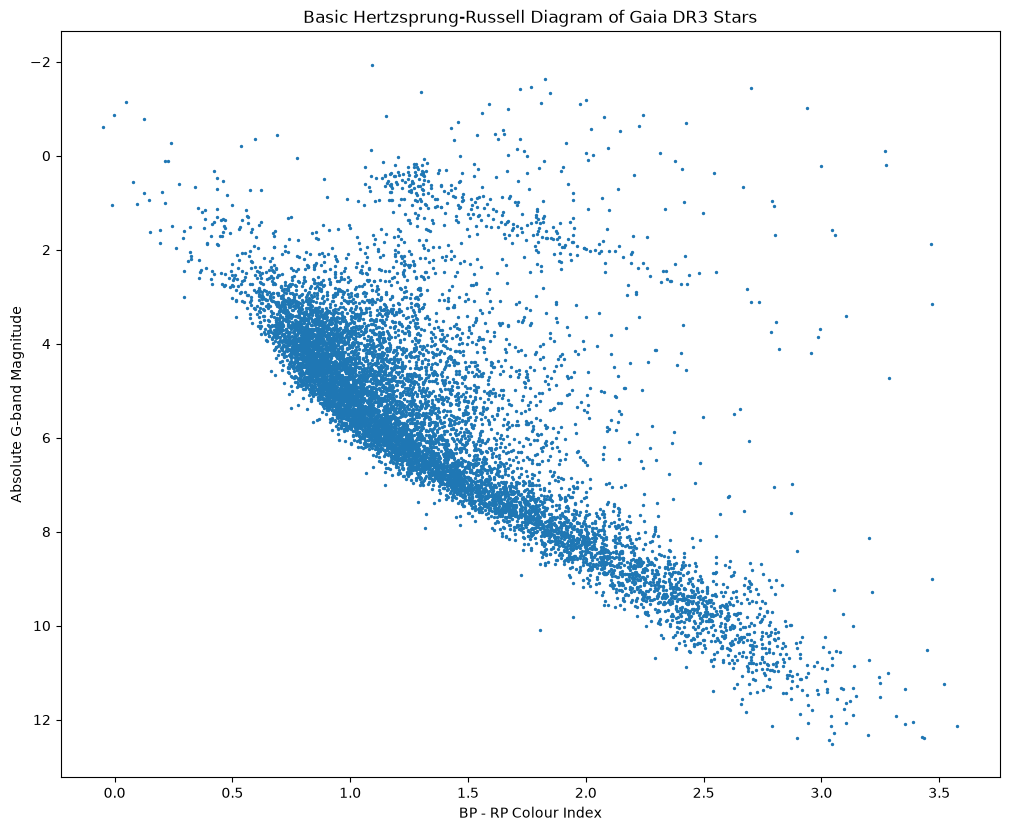

In [9]:
# plot
plt.figure(figsize=(10, 8))

plt.scatter(
    gaia_dataframe["bp_rp"], # x-axis
    gaia_dataframe["absolute_magnitude"], # y_axis
    s=2
) 

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("Basic Hertzsprung-Russell Diagram of Gaia DR3 Stars")

plt.show()

#### Discussion:

The resulting plot is generally consistent with the expected structure of an HR diagram, and indicates the derived absolute magnitudes and observed colour indices capture the relationship between stellar temperature and luminosity. 

Three broad groups of stars can be identified in the plot. The largest group forms a prominent diagonal band through the centre of the diagram and can be identified as the main sequence. A smaller concentration is located around **`absolute_magnitude = 0`**, which can broadly be associated with the giant branch. A much sparser population appears above this region and may correspond to more luminous stars, including supergiants. These classifications are based on comparison with the characteristic locations of stellar populations in established HR diagrams and should therefore be considered approximate.

Several differences from a typical HR diagram are also apparent. The main sequence in this dataset is noticeably shorter, with fewer stars extending toward its faint and luminous ends. The identified giant population is also substantially smaller than typically expected in a standard HR diagram. Most notably, there is a distinct lack of white dwarf stars in the resulting diagram. These differences may be partly explained by the relatively small sample size used in this project. However, they could also result from the specific quality filters, selection criteria, or observational limitations applied when constructing the dataset.

Another notable feature is the extended range of the **`bp_rp`** colour index. Most HR diagram show a colour range extending to approximately **`bp_rp ≈ 2.0`**, whereas the dataset used here contains values reaching approximately **`bp_rp ≈ 3.5`**. This indicates that the sample includes stars with substantially redder observed colours than those represented in some standard HR-diagram examples. This extended colour range may therefore reflect the inclusion of very cool and/or highly reddened stars, as well as differences between this dataset and the samples used to construct standard reference diagrams.

Overall, the constructed HR diagram successfully reproduces the most important qualitative feature of stellar evolution diagrams, which is the concentration of stars along the main sequence, while also revealing several differences from an idealized HR diagram. These differences are important when interpreting the following clustering results, as the incomplete representation of certain stellar populations may affect the ability of unsupervised algorithms to identify physically meaningful groups.

### Density plot:

This plot shows the density of the HR diagram above using the same **`bp_rp`** and **`absolute_magnitude`** axes. Again, this result is consistent with the fact that most stars are found on the **main sequence** of the HR diagram, as stars spend about 90% of their lifespan in this stable phase, turning hydrogen into helium in their cores.

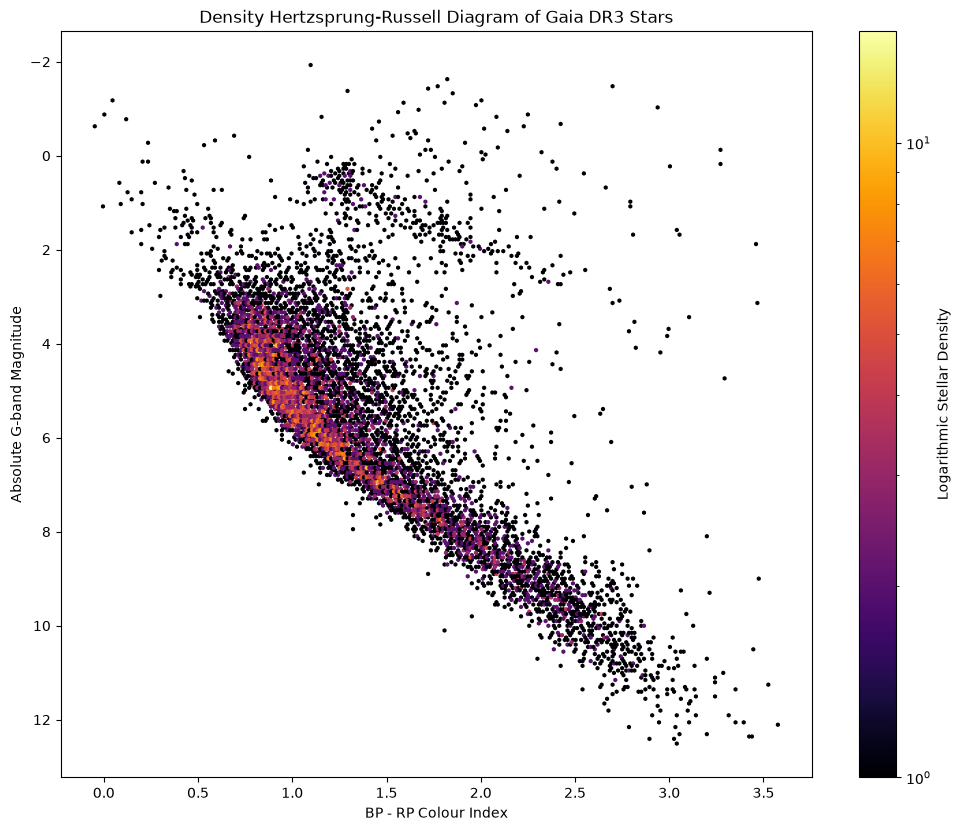

In [10]:
# plot
plt.figure(figsize=(10, 8))

plt.hexbin(
    gaia_dataframe["bp_rp"], # x-axis
    gaia_dataframe["absolute_magnitude"], # y_axis
    gridsize=250,
    bins="log",
    mincnt=1,
    cmap="inferno"
) 

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("Density Hertzsprung-Russell Diagram of Gaia DR3 Stars")

plt.colorbar(label="Logarithmic Stellar Density")

plt.show()

***

## Unsupervised Clustering on HR Diagram and analysis:

Next, we investigate whether unsupervised clustering can recover meaningful stellar structure within the HR diagram using only variables **`bp_rp`** and **`absolute_magnitude`** using methods **K-Means**, Density-Based Spatial Clustering of Applications with Noise (**DBSCAN**), and Gaussian Mixture Modelling (**GMM**).

### 1. K-Means:

K-Means is an unsupervised algorithm that clusters data into $k$ groups based on each observation's distance to a centroid, which is the mean or median of all observations. This is a very popular clustering method, since it is one of the fastest algorithms available, and very beginner friendly for learning unsupervised clustering.

#### Finding the ideal k value

K-Means requires the number of clusters ($k$) to be specified before fitting the model. To determine this $k$ value, we will use the Elbow (Inertia) method, which measures the total within-cluster sum of squared distances to the assigned centroids. As $k$ increases, inertia always decreases because each cluster contains fewer points. The aim is to identify the point beyond which adding more clusters produces only marginal improvement (the "elbow").

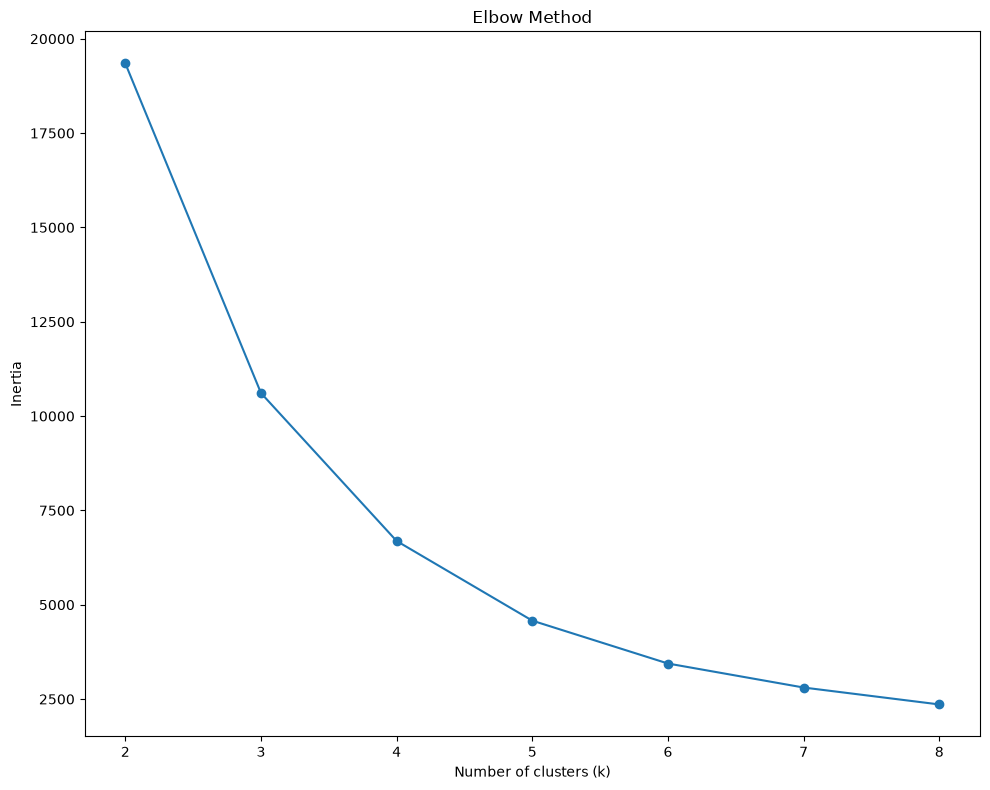

In [11]:
# elbow method (inertia) to choose best number of cluster
hr_features = gaia_dataframe[["bp_rp", "absolute_magnitude"]]

k_range = range(2, 9)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(hr_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 8))

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.tight_layout()
plt.show()

By the elbow method graph, $k=3$ shows a significant reduction in inertia. While the elbow is not perfectly sharp, it suggests that increasing the number of clusters beyond this point yields relatively little improvement in within-cluster compactness.

#### K-Means plot

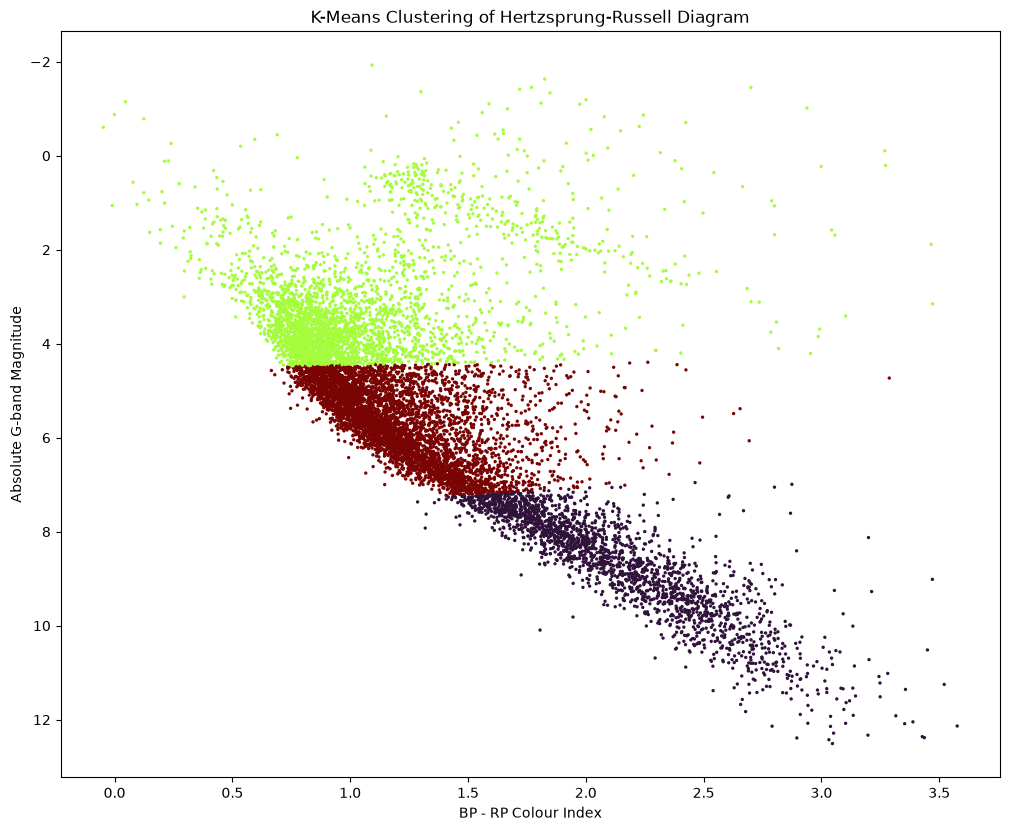

In [12]:
# K-means
hr_kmeans = KMeans(n_clusters = 3)

gaia_dataframe["k_means_clusters"] = hr_kmeans.fit_predict(hr_features)

# plot
plt.figure(figsize=(10, 8))

plt.scatter(
    gaia_dataframe["bp_rp"],
    gaia_dataframe["absolute_magnitude"],
    c=gaia_dataframe["k_means_clusters"],
    cmap="turbo",
    s=2
)

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("K-Means Clustering of Hertzsprung-Russell Diagram")

plt.show()



#### K-Means plot analysis

We observe three relatively clean clusters running approximately horizontally across the HR diagram, rather than separating the distinct stellar evolutionary groups outlined previously. This result is expected given the properties of the K-Means algorithm, since which generally performs best when data is compact, approximately spherical, and of similar size and density. In contrast, the HR diagram contains irregularly shaped data groups with varying densities and distributions.

This result highlights a well-known limitation of centroid-based clustering when applied to non-spherical and unevenly-distributed data. In terms of the original research question, K-Means did not identify three distinct stellar populations within the HR diagram. Instead, it primarily partitioned the feature space into three evenly-distributed regionsbased on distance to cluster centroids, which have little to no physical meaning in terms of underlying astrophysical populations.

***

### 2. Density-Based Spatial Clustering of Applications with Noise (DBSCAN):

DBSCAN is a density-based clustering algorithm that groups data points that are closely packed together, and marks outliers as noise based on distance metric **`eps`**. 

Another important key parameter in the DBSCAN algorithm is **`min_samples`**, which is the minimum number of points required within the **`eps`** radius to form a dense region. The chosen value of **`min_samples = 4`** is based on the convention of **`min_samples`** $>= D+1$, where $D$ is the number of dimensions in the dataset.

DBSCAN catagorizes given data points into three types: **core points**, which have at least **`min_samples`** number of neighbours within **`eps`**; **border points**, which are near core points, but lack enough neighbours to be core points; and **noise points**, which don't belong to any cluster. The algorithm then iteratively expands groups from core points to create clusters without assumptions on their shape and size.

#### Finding best eps value for DBSCAN

We will use a k-distance plot find the optimal value of **`eps`** to use in the DBSCAN algorithm. This technique calculates the average distance between each point and its k-nearest neighbours, where $k =$ **`min_samples`**, then plots the distances in ascending order on a k-distance graph. The optimal value for **`eps`** can be found at the point of maximum curvature, or where the graph has the greatest slope. 

By observation, the region of maximum curvature in the below k-distance graph is outlined in red. Two values of eps were chosen from this region (green line) after repeated testing to demonstrate the dependence of DBSCAN on value **`eps`**, which will be discussed in the next section.

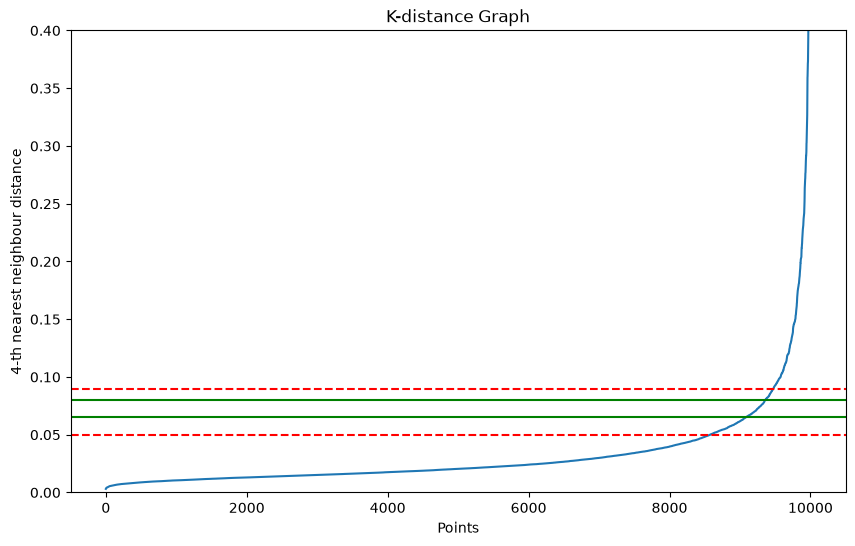

In [16]:
# function to plot k-distance graph
def plot_k_distance_graph(hr_features, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(hr_features)

    distances, _ = neigh.kneighbors(hr_features)
    distances = np.sort(distances[:, k-1])

    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.ylim(0, 0.4)
    plt.axhline(y=0.09, color='red', linestyle='--')
    plt.axhline(y=0.08, color='green', linestyle='-')
    plt.axhline(y=0.065, color='green', linestyle='-')
    plt.axhline(y=0.05, color='red', linestyle='--')

    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbour distance')
    plt.title('K-distance Graph')
    
    plt.show()

# Plot k-distance graph
plot_k_distance_graph(hr_features, k=4)

#### DBSCAN Plot 1 (eps = 0.0065)

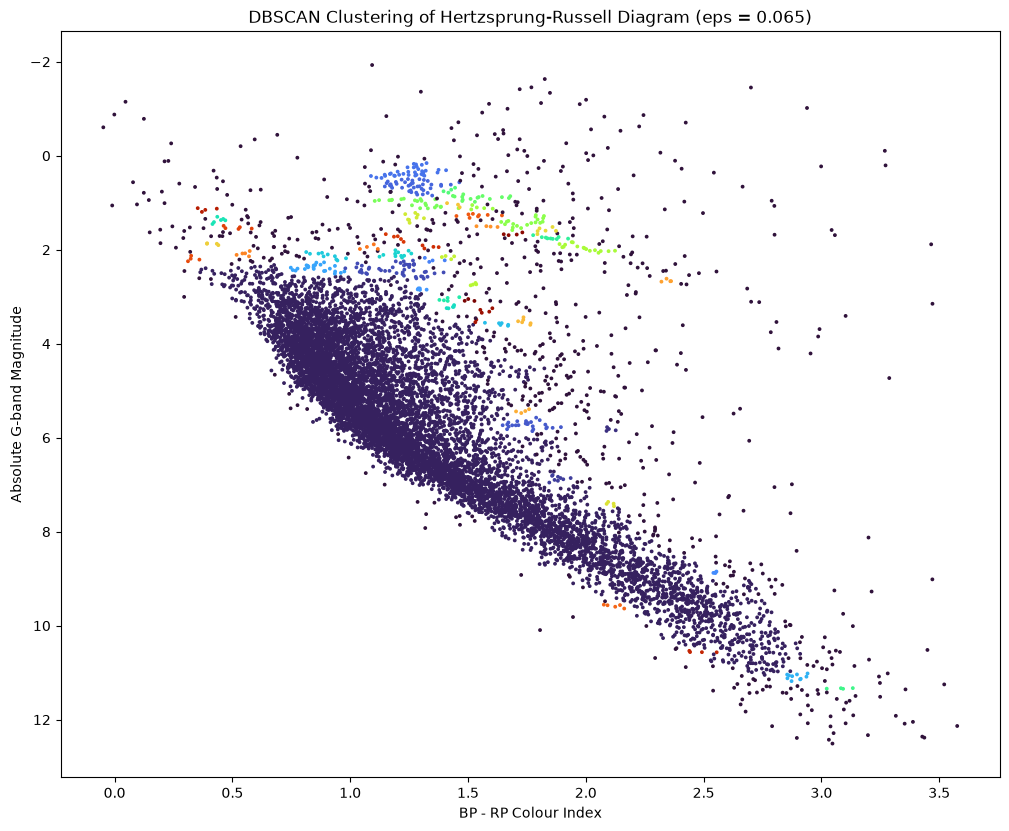

In [19]:
# DBSCAN (0.0055)
hr_features = gaia_dataframe[["bp_rp", "absolute_magnitude"]]

hr_dbscan = DBSCAN(eps = 0.065, min_samples = 4)

gaia_dataframe["dbscan_clusters"] = hr_dbscan.fit_predict(hr_features)

# plot
plt.figure(figsize=(10, 8))

plt.scatter(
    gaia_dataframe["bp_rp"],
    gaia_dataframe["absolute_magnitude"],
    c=gaia_dataframe["dbscan_clusters"],
    cmap="turbo",
    s=3
)

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("DBSCAN Clustering of Hertzsprung-Russell Diagram (eps = 0.065)")

plt.show()


#### DBSCAN Plot 2 (eps = 0.008)

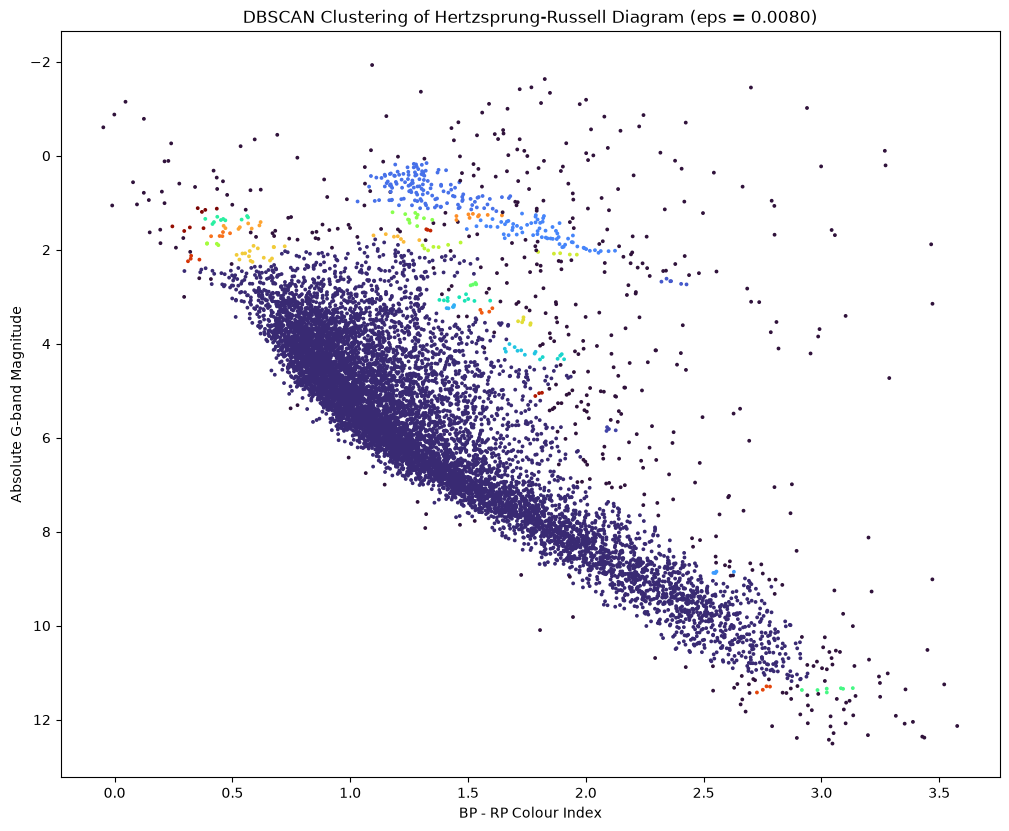

In [21]:
# DBSCAN (0.008)
hr_features = gaia_dataframe[["bp_rp", "absolute_magnitude"]]

hr_dbscan = DBSCAN(eps = 0.08, min_samples = 4)

gaia_dataframe["dbscan_clusters"] = hr_dbscan.fit_predict(hr_features)

# plot
plt.figure(figsize=(10, 8))

plt.scatter(
    gaia_dataframe["bp_rp"],
    gaia_dataframe["absolute_magnitude"],
    c=gaia_dataframe["dbscan_clusters"],
    cmap="turbo",
    s=3
)

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("DBSCAN Clustering of Hertzsprung-Russell Diagram (eps = 0.0080)")

plt.show()


#### DBSCAN plots analysis

In both DBSCAN plots, the main sequence is successfully identified as one large cluster due to its high density and characteristic shape. However, the clustering of the giants region varies extensively between the two choices of **`eps`**. For **`eps=0.0065`**, the giants group is divided into several smaller clusters, while for **`eps=0.0080`**, most of the giant region is grouped into a single cluster. 

This result highlights two important characteristics of DBSCAN. First, the algorithm struggles to distinguish intrinsic details in dense regions. Second, the clustering results can be incredibly sensitive to the choice of **`eps`**. Notably, the additional clusters in the giants region do not correspond clearly to any expected astrophysical populations.

In summary, which DBSCAN successfully captured the main sequence cluster of stars as well as revealing some structure in the giants region, it failed to capture underlying stellar populations within the highly dense region in the HR diagram.

***

### 3. Gaussian Mixture Modelling (GMM):

GMM is a probablistic model that assumes all data points are generated from a combination of $n$ normal (Gaussian) distributions with unknown parameters. This clustering method can be thoguht of as a generalization of K-Means that incorporates the covariance structure of the data as well as the centres of the assumed hidden Gaussian distribution in creating clusters.

#### Finding best n for GMM

We will use the Bayesian Information Criterion (BIC) curve, which is a statistical metric used to evaluate the goodness of fit of a model for the given data. The most optimal $n$ value will have the lowest BIC score.

Based on repeated trials with a random subset of 200 data points, $n=5$ was revealed to be most optimal.



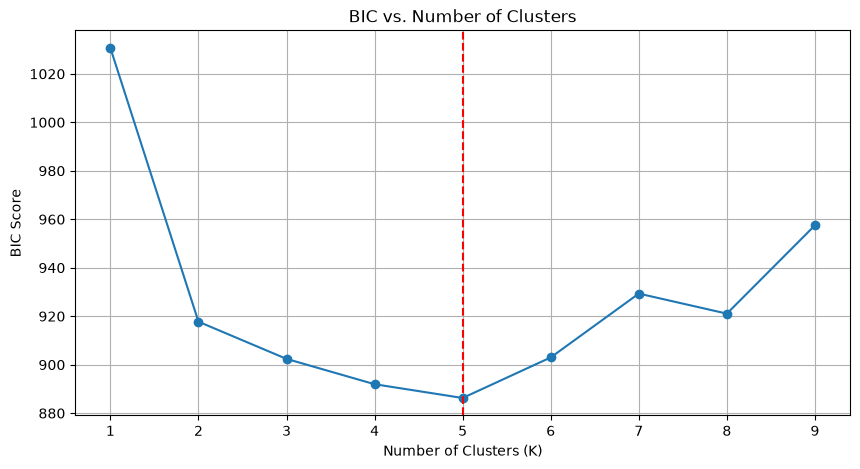

In [24]:
# function to plot BIC curve
def plot_BIC(bic, max_k):

    #Find best k
    best_k = np.argmin(bic) + 1

    plt.figure(figsize=(10,5))
    plt.plot(range(1, max_k), bic, marker="o")

    plt.axvline(
        x=best_k,
        color="red",
        linestyle="--",
        label=f"Best K: {best_k}"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("BIC Score")
    plt.title("BIC vs. Number of Clusters")

    plt.grid()
    plt.show()


hr_subset = hr_features.sample(n=200, random_state=42) # randomly choose 200 samples from dataframe to calculate BIC

bic = []

max_k = 10

#loop over test range of K
for k in range(1, max_k):
    gmm = GaussianMixture(n_components = k, covariance_type = 'full')
    gmm.fit(hr_subset)
    bic.append(gmm.bic(hr_subset))


plot_BIC(bic, max_k)

#### GMM Plot

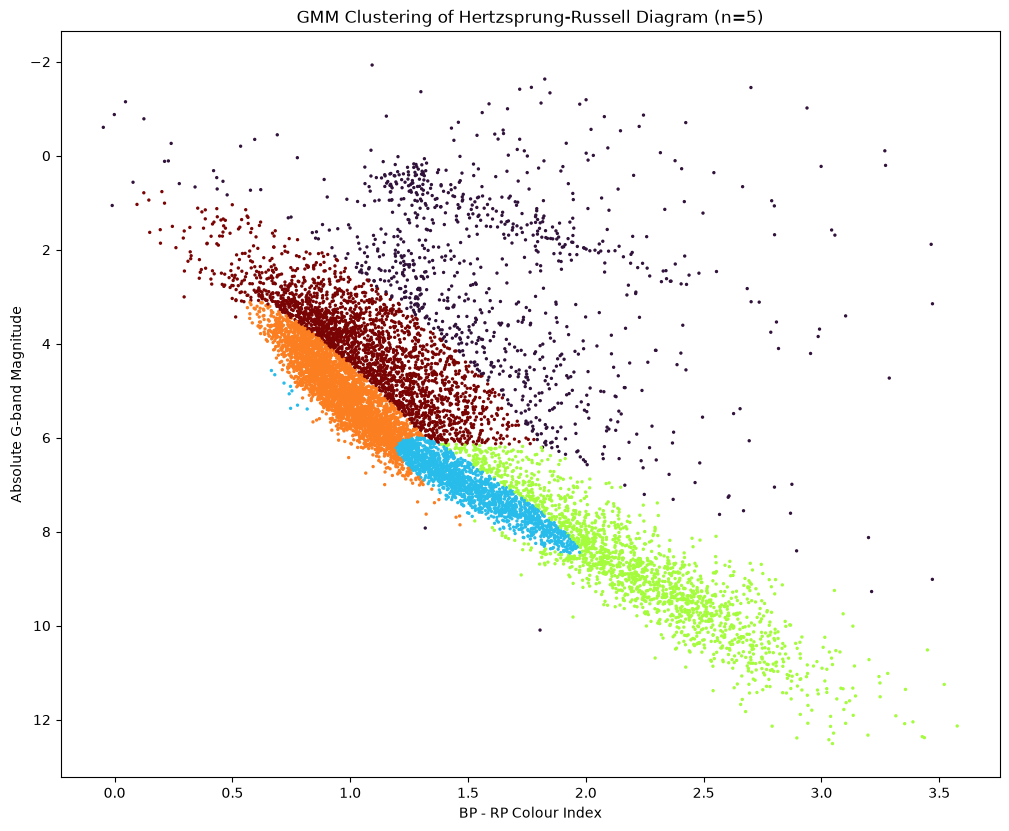

In [35]:
# GMM 
hr_features = gaia_dataframe[["bp_rp", "absolute_magnitude"]]

hr_gmm = GaussianMixture(n_components = 5)

gaia_dataframe["gmm_clusters"] = hr_gmm.fit_predict(hr_features)

# plot
plt.figure(figsize=(10, 8))

plt.scatter(
    gaia_dataframe["bp_rp"],
    gaia_dataframe["absolute_magnitude"],
    c=gaia_dataframe["gmm_clusters"],
    cmap="turbo",
    s=2
)

plt.gca().invert_yaxis() # Invert y-axis to have brighter stars at the top
plt.tight_layout()

plt.xlabel("BP - RP Colour Index")
plt.ylabel("Absolute G-band Magnitude")
plt.title("GMM Clustering of Hertzsprung-Russell Diagram (n=5)")

plt.show()


#### GMM plots analysis

We observe the plot has been clustered into 5 elliptical-like regions based on its position within the HR diagram. Compared with DBSCAN, GMM provides greater separation of different regions in the main sequence, while assigning a large additional cluster to stars outside or above the main sequence. This suggests that GMM is capable of revealing some intrinsic structure in the dense main sequence region.

The approximate interpretation of the clusters is as follows:

- **Orange cluster** : This cluster extends from **`bp_rp`** $\approx 0.6 - 1.4$ and **`absolute_magnitude`** $\approx 3 - 7.5$. It can be interpreted as containing **solar-type** main sequence stars, or stars with properties relatively similar to those of the Sun. However, this region overlaps substantially with the red cluster, indicating that GMM components do not necessarily correspond to completely distinct astrophysical populations.

- **Red cluster**: This cluster extends from **`bp_rp`** $\approx 0.0 - 2.0$ and **`absolute_magnitude`** $\approx 0 - 6$. It may contain stars located around the upper portion of the main sequence and subgiant region. However, the **`bp_rp`** distribution differs from the expected colour range and location in a conventional HR diagram. This is consistent with the axis discrepancy identified in the **Constructing the HR Diagram section**.

- **Green cluster**: This cluster ranges from **`bp_rp`** $\approx 1.3 - 3.5$ and **`absolute_magnitude`** $\approx 6 - 12$. It primarily corresponds to cooler, lower-mass stars toward the redder end of the main sequence, including many stars expected to have late spectral types such as K and M.

- **Blue cluster**: This cluster ranges from **`bp_rp`** $\approx 1.3 - 2.0$ and **`absolute_magnitude`** $\approx 6 - 8$. It appears to represent a portion of the cooler main sequence, potentially including late K-type and some M-type stars. Note that there is overlap with the green and red clusters.

- **Purple cluster**: This is the largest cluster in the resulting HR diagram, extending across the **`bp_rp`** axis while occupying the region above the main sequence. It may represent more luminous stellar populations, such as giants, bright giants, and potentially supergiants. However, because the cluster spans a broad region of the feature space, it may also include stars that do not fit neatly into these categories, or outliers from the main sequence that were not clearly separated by the GMM.


In summary, GMM was able to reveal more detailed structures within the main sequence than either K-Means or DBSCAN. However, the correspondence between the GMM components and physically distinct stellar populations is not exact. This is partly due to the elliptical Gaussian assumptions of GMM and also due to the discrepancies between the resulting HR diagram and the expected standard HR diagram structure.



***

## Conclusion and furture research directions:

This project used a quality-filtered sample of Gaia Data Release 3 (DR3) stellar data to construct a Hertzsprung–Russell (HR) diagram and investigate unsupervised clustering using K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise), and GMM (Gaussian Mixture Modelling). The objective was to determine whether these unsupervised clustering methods could recover meaningful stellar population groupings within the HR diagram, and to identify which method produced the most astronomically informative results.

The resulting HR diagram reproduced several of the expected characteristics, including a highly-dense, diagonal main sequence. This confirmed the relationship between stellar absolute magnitude and colour index. However, the plot has several deviations expected structure, including as a shorter main sequence, extended range of **`bp_rp`** values, absent white dwarfs region, and a sparce giants branch.

K-Means clustering with **`k=3`** resulted in 3 equally-spaced regions across the feature space. However, these regions do not correspond to any lcearly identifiable astrophysical groups, and instead clustered the data according to distance from the centroids. This result is consistent with the K-Mean's limitations when applied to irregular and unevenly distributed data such as those present in an HR diagram.

DBSCAN clustering with **`eps = 0.0065`** and **`eps = 0.0080`** successfully identified the main sequence as a major cluster, but failed to capture intrinsic details within the highly-dense region. Additionally, the relatively small change in **`eps`** resulted in entirely new clusters in the giants branch, which do not correspond clearly to any expected astrophysical populations. Although DBSCAN was effective at identifying the high-density structure of the main sequence, it was less successful at distinguishing the underlying stellar populations within regions of varying density.

GMM clustering with n = 5 provided the most detailed separation of the three methods tested. It revealed several regions within the main sequence that were not clearly distinguished by DBSCAN, which could be broadly associated with different stellar temperature, colour, and luminosity ranges. However, the correspondence between the Gaussian clusters and physically distinct stellar populations is not exact. The elliptical assumptions of GMM do not perfectly match the complex and non-Gaussian structure of an HR diagram, while discrepancies in the construction of our HR diagram may have further affected the resulting clusters.

In summary, based on unsupervised clustering with random Gaia DR3 data, **Gaussian Mixture Modeling (GMM) gave the best result our of the three for reconstructing the Hertzsprung-Russell diagram**. GMM was able to better capture physical properties of stars instead of pure data density or geometric distance. However, its performance is dependent on the quality of the data, the representation of the HR diagram, and the underlying assumptions of the model. 

### Future directions

Several improvements could be explored in future work:

- **Increasing the sample size**: Using a substantially larger sample of Gaia DR3 stars, such as 50,000 or more sources, could provide a more complete representation of the different stellar populations and improve the stability of clustering results.

- **Testing additional clustering methods**: Other clustering approaches, such as hierarchical clustering, spectral clustering, or more advanced density-based methods, could be applied to determine whether they are better suited to the irregular and non-uniform structure of the HR diagram.

- **Exploring different quality thresholds**: Testing different data-quality cuts could help determine how sensitive the HR diagram and clustering results are to measurement uncertainties and potentially problematic observations.

